# 🚦 Hệ thống RAG + LLM Gốc (Cấu hình B)
## Dự án cuối kỳ: Hỏi đáp Luật Giao thông Đường bộ Việt Nam

**Cấu hình B: Có RAG — LLM gốc (không fine-tune)**

| | Không RAG | Có RAG |
|---|---|---|
| **LLM gốc** | A | **B ← (file này)** |
| **LLM fine-tuned** | C | D |

### Pipeline:
```
Câu hỏi → Embedding → FAISS Retriever (top-k) → Prompt Template → LLM gốc → Câu trả lời
```

## 0. Mount Google Drive

In [1]:
from google.colab import drive, userdata
from getpass import getpass

drive.mount('/content/drive')

import os

# ========== CẤU HÌNH ĐƯỜNG DẪN ==========
DRIVE_BASE = '/content/drive/MyDrive'
DATA_PATH = os.path.join(DRIVE_BASE, 'data_RAG.json')
HUMAN_EVAL_PATH = os.path.join(DRIVE_BASE, 'human_eval_50.json')

# Tách output/cache riêng cho Config B dùng Llama, tránh load nhầm kết quả model cũ
OUTPUT_DIR = os.path.join(DRIVE_BASE, 'outputs_configB_llama')
FAISS_DIR = os.path.join(DRIVE_BASE, 'faiss_index_configB_e5')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FAISS_DIR, exist_ok=True)

print('Đã mount Drive và tạo thư mục thành công')
print(f'   data_RAG   : {DATA_PATH}')
print(f'   human_eval : {HUMAN_EVAL_PATH}')
print(f'   Output     : {OUTPUT_DIR}')
print(f'   FAISS      : {FAISS_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã mount Drive và tạo thư mục thành công
   data_RAG   : /content/drive/MyDrive/data_RAG.json
   human_eval : /content/drive/MyDrive/human_eval_50.json
   Output     : /content/drive/MyDrive/outputs_configB_llama
   FAISS      : /content/drive/MyDrive/faiss_index_configB_e5


## 1. Cài đặt thư viện

In [2]:
%%capture
!pip install -q -U transformers accelerate bitsandbytes sentencepiece "protobuf<6"
!pip install -q -U sentence-transformers faiss-cpu
!pip install -q -U rouge-score bert-score sacrebleu
!pip install -q -U pandas numpy tqdm matplotlib

print('Cài đặt hoàn tất')


In [2]:
import json, os, re, time
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import faiss

from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import sacrebleu

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 2. Tải và xử lý dữ liệu

In [3]:
# ---- Tải dữ liệu train/RAG và bộ human eval 50 câu ----
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

with open(HUMAN_EVAL_PATH, 'r', encoding='utf-8') as f:
    human_eval_raw = json.load(f)

assert len(raw_data) >= 300, 'data_RAG.json cần có ít nhất 300 mẫu.'
assert len(human_eval_raw) >= 50, 'human_eval_50.json cần có ít nhất 50 câu.'
assert set(raw_data[0].keys()) >= {'Q', 'C', 'A'}, 'data_RAG.json phải có Q, C, A.'
assert set(human_eval_raw[0].keys()) >= {'Q', 'A'}, 'human_eval_50.json phải có Q, A.'

print(f'✅ data_RAG      : {len(raw_data)} mẫu')
print(f'✅ human_eval_50 : {len(human_eval_raw)} câu')


def normalize_space(text: str) -> str:
    return re.sub(r'\s+', ' ', str(text or '')).strip()


def extract_question(q_raw: str) -> str:
    """Trích câu hỏi thuần từ trường Q."""
    q = str(q_raw or '').strip()
    for prefix in ['Câu hỏi:\n', '### Câu hỏi:\n', 'Câu hỏi:', '### Câu hỏi:']:
        if q.startswith(prefix):
            q = q[len(prefix):].strip()
            break
    q = re.sub(r'\n*#+\s*Trả lời:\s*$', '', q).strip()
    return normalize_space(q)


def extract_context(c_raw) -> str:
    """Trích phần ngữ cảnh từ trường C của data_RAG."""
    if isinstance(c_raw, dict):
        parts = []
        for value in c_raw.values():
            if isinstance(value, dict):
                parts.append(str(value.get('text', '')))
            else:
                parts.append(str(value))
        context = '\n'.join(parts)
    else:
        context = str(c_raw or '')

    if '### Ngữ cảnh:' in context:
        context = context.split('### Ngữ cảnh:', 1)[1].strip()
    for marker in ['### Câu hỏi:', '### Trả lời:']:
        if marker in context:
            context = context.split(marker, 1)[0].strip()
    return normalize_space(context)


records = []
for item in raw_data:
    q = extract_question(item.get('Q', ''))
    c = extract_context(item.get('C', ''))
    a = normalize_space(item.get('A', ''))
    if q and c and a:
        records.append({'question': q, 'context': c, 'answer': a})

human_eval_records = []
for item in human_eval_raw[:50]:
    q = extract_question(item.get('Q', ''))
    a = normalize_space(item.get('A', ''))
    if q and a:
        human_eval_records.append({'question': q, 'answer': a})

df = pd.DataFrame(records)
print(f'\nKnowledge-base QA records: {len(df)}')
print(df[['question', 'answer']].head(3).to_string())

print(f'\nHuman eval records: {len(human_eval_records)}')
print(pd.DataFrame(human_eval_records).head(3).to_string())


✅ data_RAG      : 350 mẫu
✅ human_eval_50 : 50 câu

Knowledge-base QA records: 350
                                                                      question                                                                                                                                                                                             answer
0  Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?                                                                                                                                                                          Ngày 01 tháng 01 năm 2025
1               Khoản 3 Điều 10 của Luật này có hiệu lực thi hành từ ngày nào?                                                                                                                                                                          Ngày 01 tháng 01 năm 2026
2            Trật tự, an toàn giao thông đường bộ được định nghĩa như thế nào?  Là trạng thái g

In [4]:
# ---- Test set đúng đề: human_eval_50.json ----
TEST_SIZE = 50
df_test = pd.DataFrame(human_eval_records).head(TEST_SIZE).reset_index(drop=True)

# Knowledge base = toàn bộ context từ data_RAG.json
# Không lấy đáp án human_eval làm corpus, chỉ dùng data_RAG để build vector store.
all_contexts = df['context'].tolist()

print(f'Test set source: human_eval_50.json')
print(f'Test set       : {len(df_test)} câu')
print(f'Corpus         : {len(all_contexts)} đoạn context từ data_RAG')
print(f'Config         : B = RAG + base LLM, không fine-tune')
print('\nVí dụ câu hỏi human eval:')
for q in df_test['question'].head(3):
    print(f'  • {q}')


Test set source: human_eval_50.json
Test set       : 50 câu
Corpus         : 350 đoạn context từ data_RAG
Config         : B = RAG + base LLM, không fine-tune

Ví dụ câu hỏi human eval:
  • Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?
  • Khi tham gia giao thông, người đi bộ phải đi ở đâu?
  • Người điều khiển phương tiện tham gia giao thông phải mang theo những giấy tờ gì khi điều khiển xe ô tô?


## 3. Xây dựng Knowledge Base & FAISS Index

In [5]:
# ---- Chunking corpus ----
CHUNK_MAX_CHARS = 700
CHUNK_OVERLAP = 100


def split_into_chunks(text: str, max_chars: int = CHUNK_MAX_CHARS, overlap: int = CHUNK_OVERLAP) -> list:
    """Chia context thành chunk theo câu, có overlap thật bằng ký tự."""
    text = normalize_space(text)
    if not text:
        return []
    if len(text) <= max_chars:
        return [text]

    sentences = re.split(r'(?<=[.!?。！？])\s+', text)
    chunks, current = [], ''

    for sent in sentences:
        sent = sent.strip()
        if not sent:
            continue

        if not current:
            current = sent
        elif len(current) + 1 + len(sent) <= max_chars:
            current = f'{current} {sent}'
        else:
            chunks.append(current.strip())
            tail = current[-overlap:].strip() if overlap > 0 else ''
            current = f'{tail} {sent}'.strip() if tail else sent

    if current:
        chunks.append(current.strip())

    return chunks


corpus_chunks = []
for ctx in all_contexts:
    corpus_chunks.extend(split_into_chunks(ctx))

# Loại duplicate nhưng vẫn giữ thứ tự
corpus_chunks = list(dict.fromkeys(corpus_chunks))

print(f'✅ Tổng số chunks: {len(corpus_chunks)}')
print(f'Chunk max chars : {CHUNK_MAX_CHARS}')
print(f'Chunk overlap   : {CHUNK_OVERLAP}')
print('\nVí dụ chunk:')
print(corpus_chunks[0][:300], '...')


✅ Tổng số chunks: 1649
Chunk max chars : 700
Chunk overlap   : 100

Ví dụ chunk:
Điều 88. Hiệu lực thi hành 1. Luật này có hiệu lực thi hành từ ngày 01 tháng 01 năm 2025, trừ trường hợp quy định tại khoản 2 Điều này. 2. Khoản 3 Điều 10 của Luật này có hiệu lực thi hành từ ngày 01 tháng 01 năm 2026. 3. Luật Giao thông đường bộ số 23/2008/QH12 đã được sửa đổi, bổ sung một số điều  ...


In [6]:
# ---- Embedding với Sentence Transformers + FAISS ----
# e5 là embedding model đa ngôn ngữ mạnh, dùng prefix query/passsage theo khuyến nghị của model.
EMBED_MODEL_NAME = 'intfloat/multilingual-e5-base'

print(f'📥 Tải embedding model: {EMBED_MODEL_NAME}')
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=device)
print('✅ Tải xong')

FAISS_INDEX_PATH = os.path.join(FAISS_DIR, 'corpus_e5.index')
FAISS_CHUNKS_PATH = os.path.join(FAISS_DIR, 'corpus_chunks_e5.json')

if os.path.exists(FAISS_INDEX_PATH) and os.path.exists(FAISS_CHUNKS_PATH):
    print('📂 Tải FAISS index từ Drive...')
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    with open(FAISS_CHUNKS_PATH, 'r', encoding='utf-8') as f:
        corpus_chunks = json.load(f)
    print(f'✅ Tải xong. Index size: {faiss_index.ntotal}')
else:
    print('\n⚙️  Đang encode corpus...')
    corpus_embeddings = embedder.encode(
        [f'passage: {chunk}' for chunk in corpus_chunks],
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    dim = corpus_embeddings.shape[1]
    print(f'\n✅ Embedding shape: {corpus_embeddings.shape}')

    faiss_index = faiss.IndexFlatIP(dim)
    faiss_index.add(corpus_embeddings)
    print(f'✅ FAISS index: {faiss_index.ntotal} vectors, dim={dim}')

    faiss.write_index(faiss_index, FAISS_INDEX_PATH)
    with open(FAISS_CHUNKS_PATH, 'w', encoding='utf-8') as f:
        json.dump(corpus_chunks, f, ensure_ascii=False, indent=2)
    print(f'💾 Đã lưu FAISS index vào Drive: {FAISS_DIR}')


📥 Tải embedding model: intfloat/multilingual-e5-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

✅ Tải xong

⚙️  Đang encode corpus...


Batches:   0%|          | 0/52 [00:00<?, ?it/s]


✅ Embedding shape: (1649, 768)
✅ FAISS index: 1649 vectors, dim=768
💾 Đã lưu FAISS index vào Drive: /content/drive/MyDrive/faiss_index_configB_e5


In [7]:
# ---- Retriever ----
TOP_K = 5


def retrieve(query: str, top_k: int = TOP_K) -> list:
    """Retrieve top-k chunks liên quan nhất cho query."""
    clean_query = extract_question(query)
    q_emb = embedder.encode(
        [f'query: {clean_query}'],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    scores, indices = faiss_index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            results.append({'chunk': corpus_chunks[idx], 'score': float(score), 'chunk_id': int(idx)})
    return results


# Test retriever trên human_eval_50
test_q = df_test['question'].iloc[0]
retrieved = retrieve(test_q)
print(f'Query: {test_q}')
print(f'\nTop-{TOP_K} retrieved chunks:')
for i, r in enumerate(retrieved, 1):
    print(f'\n[{i}] Score={r["score"]:.4f} | chunk_id={r["chunk_id"]}')
    print(r['chunk'][:250], '...')


Query: Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?

Top-5 retrieved chunks:

[1] Score=0.8455 | chunk_id=1243
soát quân sự, kiểm tra xe quân sự trên đường bộ thực hiện theo quy định của Bộ trưởng Bộ Quốc phòng. QUẢN LÝ NHÀ NƯỚC VỀ TRẬT TỰ, AN TOÀN GIAO THÔNG ĐƯỜNG BỘ Điều 86. Nội dung quản lý nhà nước về trật tự, an toàn giao thông đường bộ 1. Chính phủ thốn ...

[2] Score=0.8451 | chunk_id=965
rật tự, an toàn giao thông đường bộ trên các phương tiện thông tin, truyền thông đại chúng. Điều 43. Trách nhiệm của cơ sở đăng kiểm, chủ xe cơ giới, xe máy chuyên dùng và người điều khiển xe cơ giới, xe máy chuyên dùng Cơ sở đăng kiểm chịu trách nhi ...

[3] Score=0.8442 | chunk_id=904
khi đi qua nơi xảy ra vụ tai nạn giao thông đường bộ có trách nhiệm chở người bị thương đi cấp cứu. Xe ưu tiên, xe chở người được hưởng quyền ưu đãi, miễn trừ ngoại giao không bắt buộc thực hiện quy định tại khoản này. QUẢN LÝ NHÀ NƯỚC VỀ TRẬT TỰ, AN ...

[4] Score=0.8430 | chunk_id=52

## 4. Tải LLM Gốc (Không Fine-tune)

In [8]:
# ---- Chọn LLM gốc cho Config B ----
# M dùng chung họ Llama với các cấu hình fine-tune để so sánh công bằng hơn.
# Lưu ý: tên đúng trên Hugging Face có dấu '-' là Llama-3.2, không phải Llama3.2.
BASE_MODEL_NAME = 'meta-llama/Llama-3.2-3B-Instruct'


def get_hf_token():
    token = os.environ.get('HF_TOKEN')
    if token:
        return token
    try:
        token = userdata.get('HF_TOKEN')
        if token:
            return token
    except Exception:
        pass
    return getpass('Nhập HF_TOKEN: ').strip()


HF_TOKEN = get_hf_token()

# Cấu hình 4-bit quantization để vừa Colab T4.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f'📥 Tải base LLM: {BASE_MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, token=HF_TOKEN, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    token=HF_TOKEN,
    quantization_config=bnb_config,
    device_map='auto',
    low_cpu_mem_usage=True,
)
model.eval()

print('✅ Tải model thành công')
if device == 'cuda':
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f'   VRAM đang dùng: {allocated:.2f} GB')


Nhập HF_TOKEN: ··········
📥 Tải base LLM: meta-llama/Llama-3.2-3B-Instruct


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Tải model thành công
   VRAM đang dùng: 3.38 GB


## 5. Prompt Template & Pipeline RAG

In [9]:
# ---- Prompt Template & Pipeline RAG ----
MAX_INPUT_TOKENS = 2048
MAX_NEW_TOKENS = 256

SYSTEM_PROMPT = """Bạn là trợ lý hỏi đáp chuyên về Luật Trật tự, An toàn Giao thông Đường bộ Việt Nam.
Nhiệm vụ của bạn là trả lời câu hỏi DỰA TRÊN ngữ cảnh được cung cấp.
Quy tắc:
- Chỉ sử dụng thông tin trong ngữ cảnh để trả lời.
- Trả lời ngắn gọn, chính xác, đúng trọng tâm.
- Nếu không tìm thấy câu trả lời trong ngữ cảnh, hãy nói: "Tôi không tìm thấy thông tin này trong tài liệu."
- Trả lời bằng tiếng Việt."""


def build_rag_prompt(question: str, retrieved_chunks: list) -> str:
    """Tạo prompt RAG với ngữ cảnh được retrieve."""
    context_text = '\n\n'.join(
        [f'[Đoạn {i+1} | score={r["score"]:.4f}]: {r["chunk"]}' for i, r in enumerate(retrieved_chunks)]
    )
    return f"""Ngữ cảnh:
{context_text}

Câu hỏi: {extract_question(question)}

Trả lời:"""


def post_process_answer(text: str) -> str:
    text = str(text or '').strip()
    for stop in ['### Câu hỏi:', '### Hướng dẫn:', '### Ngữ cảnh:', '### Trả lời:', '\nQ:', '\nA:', '\nLý do', '\nGiải thích']:
        idx = text.find(stop)
        if idx != -1:
            text = text[:idx].strip()
    text = text.split('\n\n', 1)[0].strip()
    text = re.sub(r'\s+', ' ', text)
    if text.endswith(';'):
        text = text[:-1] + '.'
    return text.strip()


def generate_answer(question: str, max_new_tokens: int = MAX_NEW_TOKENS) -> dict:
    """Pipeline RAG hoàn chỉnh: retrieve → prompt → base LLM → answer."""
    retrieved = retrieve(question, top_k=TOP_K)
    user_msg = build_rag_prompt(question, retrieved)

    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_msg},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_INPUT_TOKENS).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    input_len = inputs['input_ids'].shape[1]
    generated = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True, clean_up_tokenization_spaces=False)

    return {
        'question': extract_question(question),
        'prediction': post_process_answer(generated),
        'retrieved': retrieved,
    }


# ---- Test nhanh ----
sample_q = df_test['question'].iloc[0]
sample_a = df_test['answer'].iloc[0]
result = generate_answer(sample_q)

print(f'❓ Câu hỏi  : {result["question"]}')
print(f'🤖 Dự đoán  : {result["prediction"]}')
print(f'✅ Đáp án   : {sample_a}')
print('\nTop context:')
print(result['retrieved'][0]['chunk'][:500])


❓ Câu hỏi  : Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?
🤖 Dự đoán  : Luật Trậtự, an toàin giao thông đươc ban hành bởi Quốc hội.
✅ Đáp án   : Quốc hội.

Top context:
soát quân sự, kiểm tra xe quân sự trên đường bộ thực hiện theo quy định của Bộ trưởng Bộ Quốc phòng. QUẢN LÝ NHÀ NƯỚC VỀ TRẬT TỰ, AN TOÀN GIAO THÔNG ĐƯỜNG BỘ Điều 86. Nội dung quản lý nhà nước về trật tự, an toàn giao thông đường bộ 1. Chính phủ thống nhất quản lý nhà nước về trật tự, an toàn giao thông đường bộ. 2. Bộ Công an là cơ quan đầu mối giúp Chính phủ thực hiện thống nhất quản lý nhà nước về trật tự, an toàn giao thông đường bộ; xây dựng lực lượng Cảnh sát giao thông chính quy, tinh nhu


## 6. Sinh câu trả lời cho toàn bộ test set

In [10]:
RESULTS_PATH = os.path.join(OUTPUT_DIR, 'predictions_configB_llama_human_eval_50.json')
FORCE_REGENERATE = False

if os.path.exists(RESULTS_PATH) and not FORCE_REGENERATE:
    print(f'📂 Tải kết quả cũ từ: {RESULTS_PATH}')
    with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
        all_results = json.load(f)
else:
    all_results = []
    print(f'⚙️  Đang sinh câu trả lời cho {len(df_test)} câu human eval...')
    for i, row in tqdm(df_test.iterrows(), total=len(df_test)):
        try:
            result = generate_answer(row['question'])
            all_results.append({
                'idx': int(i),
                'question': row['question'],
                'reference': row['answer'],
                'prediction': result['prediction'],
                # Lưu full chunk để tính Recall@5 và kiểm tra nguồn, không cắt 200 ký tự nữa.
                'retrieved': [
                    {
                        'chunk': r['chunk'],
                        'score': r['score'],
                        'chunk_id': r['chunk_id'],
                    }
                    for r in result['retrieved']
                ],
            })
        except Exception as e:
            print(f'\n⚠️  Lỗi tại câu {i}: {e}')
            all_results.append({
                'idx': int(i),
                'question': row['question'],
                'reference': row['answer'],
                'prediction': '',
                'retrieved': [],
                'error': str(e),
            })

    with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)
    print(f'\n💾 Đã lưu: {RESULTS_PATH}')

print(f'✅ Tổng kết quả: {len(all_results)}')


⚙️  Đang sinh câu trả lời cho 50 câu human eval...


  0%|          | 0/50 [00:00<?, ?it/s]


💾 Đã lưu: /content/drive/MyDrive/outputs_configB_llama/predictions_configB_llama_human_eval_50.json
✅ Tổng kết quả: 50


## 7. Đánh giá định lượng

In [11]:
# ---- BLEU Score ----
def compute_bleu(references: list, predictions: list) -> float:
    """Tính BLEU-4, trả về thang 0-1 để đồng bộ với ROUGE/BERTScore."""
    safe_predictions = [p if str(p).strip() else '.' for p in predictions]
    bleu = sacrebleu.corpus_bleu(safe_predictions, [references])
    return bleu.score / 100


# ---- ROUGE-L Score ----
def compute_rouge_l(references: list, predictions: list) -> dict:
    """Tính ROUGE-L Precision, Recall, F1."""
    scorer_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    p_list, r_list, f_list = [], [], []
    for ref, pred in zip(references, predictions):
        pred = pred if str(pred).strip() else '.'
        scores = scorer_obj.score(str(ref), str(pred))
        p_list.append(scores['rougeL'].precision)
        r_list.append(scores['rougeL'].recall)
        f_list.append(scores['rougeL'].fmeasure)
    return {
        'precision': float(np.mean(p_list)),
        'recall': float(np.mean(r_list)),
        'f1': float(np.mean(f_list)),
    }


# ---- Recall@K proxy cho Retrieval ----
# human_eval_50.json chưa có gold chunk_id, nên Recall@5 được tính bằng keyword proxy:
# nếu keyword quan trọng của đáp án xuất hiện trong top-5 retrieved chunks thì tính là hit.
STOPWORDS = {
    'của','và','được','trong','các','theo','tại','khi','đến','từ','với','về','này','một','cho','trên',
    'không','người','phương','tiện','giao','thông','đường','phải','luật','điều','khoản','điểm','hoặc',
    'quy','định','tham','gia','bằng','những','cũng','như','nếu','thì','là','có','an','toàn','trật','tự',
}


def answer_keywords(answer: str) -> list:
    tokens = re.findall(r'\d+[\d/.-]*|[a-zA-ZÀ-ỹ]+', str(answer).lower())
    keywords = []
    for tok in tokens:
        if tok in STOPWORDS:
            continue
        if tok.isdigit() or len(tok) >= 4:
            keywords.append(tok)
    return keywords[:12]


def retrieved_to_text(retrieved_items: list) -> str:
    parts = []
    for item in retrieved_items:
        if isinstance(item, dict):
            parts.append(str(item.get('chunk', '')))
        else:
            parts.append(str(item))
    return ' '.join(parts).lower()


def compute_recall_at_k(results: list, k: int = 5):
    hits, usable = 0, 0
    details = []
    for result in results:
        keywords = answer_keywords(result.get('reference', ''))
        if not keywords:
            continue
        usable += 1
        retrieved_text = retrieved_to_text(result.get('retrieved', [])[:k])
        threshold = 1 if len(keywords) <= 2 else 2
        matched = [kw for kw in keywords if kw in retrieved_text]
        ok = len(matched) >= threshold
        hits += int(ok)
        details.append({
            'question': result.get('question', ''),
            'reference': result.get('reference', ''),
            'keywords': keywords,
            'matched': matched,
            'hit': bool(ok),
        })
    return hits / max(1, usable), details


print('✅ Hàm đánh giá đã sẵn sàng')


✅ Hàm đánh giá đã sẵn sàng


In [12]:
# ---- Tính tất cả metrics trên human_eval_50 ----
references = [r['reference'] for r in all_results]
predictions = [r['prediction'] if str(r.get('prediction', '')).strip() else '.' for r in all_results]

print('⚙️  Đang tính BLEU...')
bleu = compute_bleu(references, predictions)

print('⚙️  Đang tính ROUGE-L...')
rouge = compute_rouge_l(references, predictions)

print('⚙️  Đang tính BERTScore (có thể mất vài phút)...')
P, R, F1 = bert_score_fn(
    predictions,
    references,
    lang='vi',
    model_type='bert-base-multilingual-cased',
    verbose=False,
)
bert_f1 = float(F1.mean().item())

print('⚙️  Đang tính Recall@5...')
recall_at_5, recall_details = compute_recall_at_k(all_results, k=TOP_K)

print('\n' + '='*62)
print('           📊 KẾT QUẢ ĐÁNH GIÁ — CẤU HÌNH B')
print('           RAG + Llama-3.2-3B-Instruct gốc, không fine-tune')
print('           Test chính: human_eval_50.json')
print('='*62)
print(f'  BLEU-4      : {bleu:.4f}')
print(f'  ROUGE-L P   : {rouge["precision"]:.4f}')
print(f'  ROUGE-L R   : {rouge["recall"]:.4f}')
print(f'  ROUGE-L F1  : {rouge["f1"]:.4f}')
print(f'  BERTScore F1: {bert_f1:.4f}')
print(f'  Recall@{TOP_K}   : {recall_at_5:.4f}')
print('='*62)


⚙️  Đang tính BLEU...
⚙️  Đang tính ROUGE-L...
⚙️  Đang tính BERTScore (có thể mất vài phút)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚙️  Đang tính Recall@5...

           📊 KẾT QUẢ ĐÁNH GIÁ — CẤU HÌNH B
           RAG + Llama-3.2-3B-Instruct gốc, không fine-tune
           Test chính: human_eval_50.json
  BLEU-4      : 0.0399
  ROUGE-L P   : 0.3480
  ROUGE-L R   : 0.4807
  ROUGE-L F1  : 0.3401
  BERTScore F1: 0.7400
  Recall@5   : 0.9400


In [13]:
# ---- Lưu metrics vào Drive ----
metrics = {
    'config': 'B - RAG + base LLM, no fine-tune',
    'model': BASE_MODEL_NAME,
    'embed_model': EMBED_MODEL_NAME,
    'test_source': 'human_eval_50.json',
    'train_rag_source': 'data_RAG.json',
    'num_kb_qa_records': int(len(df)),
    'test_size': int(len(all_results)),
    'top_k': TOP_K,
    'chunk_max_chars': CHUNK_MAX_CHARS,
    'chunk_overlap': CHUNK_OVERLAP,
    'bleu4': round(float(bleu), 4),
    'rouge_l_p': round(float(rouge['precision']), 4),
    'rouge_l_r': round(float(rouge['recall']), 4),
    'rouge_l_f1': round(float(rouge['f1']), 4),
    'bertscore_f1': round(float(bert_f1), 4),
    'recall_at_5': round(float(recall_at_5), 4),
    'recall_note': 'Recall@5 dùng keyword proxy vì human_eval_50.json chưa có gold chunk_id/evidence id.',
}

METRICS_PATH = os.path.join(OUTPUT_DIR, 'metrics_configB_llama_human_eval_50.json')
RECALL_DETAILS_PATH = os.path.join(OUTPUT_DIR, 'recall_details_configB_llama_human_eval_50.json')

with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

with open(RECALL_DETAILS_PATH, 'w', encoding='utf-8') as f:
    json.dump(recall_details, f, ensure_ascii=False, indent=2)

print(f'💾 Đã lưu metrics: {METRICS_PATH}')
print(f'💾 Đã lưu recall details: {RECALL_DETAILS_PATH}')
print(json.dumps(metrics, ensure_ascii=False, indent=2))


💾 Đã lưu metrics: /content/drive/MyDrive/outputs_configB_llama/metrics_configB_llama_human_eval_50.json
💾 Đã lưu recall details: /content/drive/MyDrive/outputs_configB_llama/recall_details_configB_llama_human_eval_50.json
{
  "config": "B - RAG + base LLM, no fine-tune",
  "model": "meta-llama/Llama-3.2-3B-Instruct",
  "embed_model": "intfloat/multilingual-e5-base",
  "test_source": "human_eval_50.json",
  "train_rag_source": "data_RAG.json",
  "num_kb_qa_records": 350,
  "test_size": 50,
  "top_k": 5,
  "chunk_max_chars": 700,
  "chunk_overlap": 100,
  "bleu4": 0.0399,
  "rouge_l_p": 0.348,
  "rouge_l_r": 0.4807,
  "rouge_l_f1": 0.3401,
  "bertscore_f1": 0.74,
  "recall_at_5": 0.94,
  "recall_note": "Recall@5 dùng keyword proxy vì human_eval_50.json chưa có gold chunk_id/evidence id."
}


## 8. Human Evaluation (50 câu)

In [14]:
# ---- Bảng chấm thủ công bổ sung cho human evaluation ----
# File này để người chấm điền điểm 1-5. Bộ câu hỏi đã lấy từ human_eval_50.json ở trên.
human_scoring_rows = []
for r in all_results:
    human_scoring_rows.append({
        'Câu hỏi': r['question'],
        'Đáp án chuẩn': r['reference'],
        'Dự đoán Config B': r['prediction'],
        'Điểm độ chính xác (1-5)': '',
        'Điểm độ liên quan (1-5)': '',
        'Điểm độ mạch lạc (1-5)': '',
        'Ghi chú': '',
    })

df_human_scoring = pd.DataFrame(human_scoring_rows)

HUMAN_SCORING_PATH = os.path.join(OUTPUT_DIR, 'human_scoring_configB_llama.csv')
df_human_scoring.to_csv(HUMAN_SCORING_PATH, index=False, encoding='utf-8-sig')

print(f'💾 Đã lưu bảng chấm tay: {HUMAN_SCORING_PATH}')
print(f'   Số câu: {len(df_human_scoring)}')
df_human_scoring[['Câu hỏi', 'Đáp án chuẩn', 'Dự đoán Config B']].head(3)


💾 Đã lưu bảng chấm tay: /content/drive/MyDrive/outputs_configB_llama/human_scoring_configB_llama.csv
   Số câu: 50


,Câu hỏi,Đáp án chuẩn,Dự đoán Config B
0,"Luật Trật tự, an toàn giao thông đường bộ 2024...",Quốc hội.,"Luật Trậtự, an toàin giao thông đươc ban hành ..."
1,"Khi tham gia giao thông, người đi bộ phải đi ở...","Phải đi trên vỉa hè, lề đường; trường hợp đườn...","Người đi bộ MUST đi trên Vỉa Hè hoặc Lề Đường,..."
2,Người điều khiển phương tiện tham gia giao thô...,Giấy phép lái xe phù hợp với loại xe đang điều...,Theo Điều 57 của Luật Trách nhiệm dân sinh về ...


## 9. Phân tích & Hiển thị kết quả

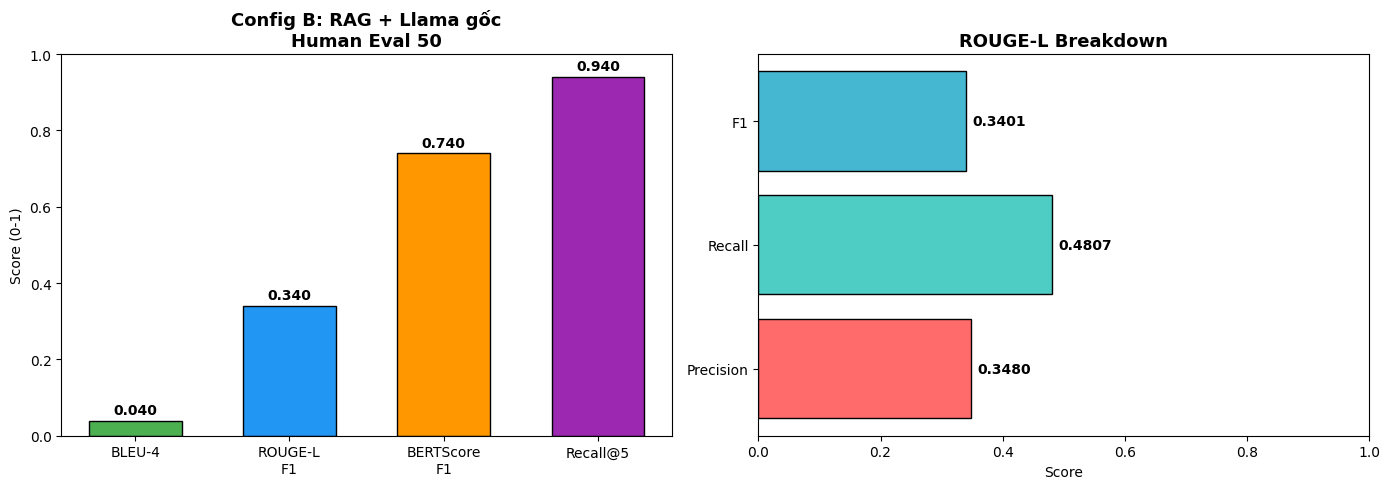

💾 Đã lưu biểu đồ: /content/drive/MyDrive/outputs_configB_llama/metrics_plot_configB_llama_human_eval_50.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ---- Biểu đồ metrics ----
metric_names = ['BLEU-4', 'ROUGE-L\nF1', 'BERTScore\nF1', 'Recall@5']
metric_values = [bleu, rouge['f1'], bert_f1, recall_at_5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = axes[0].bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.6)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Config B: RAG + Llama gốc\nHuman Eval 50', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score (0-1)')
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

rouge_labels = ['Precision', 'Recall', 'F1']
rouge_vals = [rouge['precision'], rouge['recall'], rouge['f1']]
axes[1].barh(rouge_labels, rouge_vals, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('ROUGE-L Breakdown', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score')
for i, v in enumerate(rouge_vals):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
PLOT_PATH = os.path.join(OUTPUT_DIR, 'metrics_plot_configB_llama_human_eval_50.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Đã lưu biểu đồ: {PLOT_PATH}')


In [16]:
# ---- Xem một số ví dụ dự đoán ----
print('=' * 70)
print('                   VÍ DỤ KẾT QUẢ DỰ ĐOÁN (5 câu đầu)')
print('=' * 70)
for i, r in enumerate(all_results[:5], 1):
    print(f'\n[{i}] ❓ Câu hỏi  : {r["question"]}')
    print(f'     ✅ Đáp án   : {r["reference"]}')
    print(f'     🤖 Dự đoán  : {r["prediction"][:200]}'
          + ('...' if len(r['prediction']) > 200 else ''))
    print('-' * 70)

                   VÍ DỤ KẾT QUẢ DỰ ĐOÁN (5 câu đầu)

[1] ❓ Câu hỏi  : Luật Trật tự, an toàn giao thông đường bộ 2024 do cơ quan nào ban hành?
     ✅ Đáp án   : Quốc hội.
     🤖 Dự đoán  : Luật Trậtự, an toàin giao thông đươc ban hành bởi Quốc hội.
----------------------------------------------------------------------

[2] ❓ Câu hỏi  : Khi tham gia giao thông, người đi bộ phải đi ở đâu?
     ✅ Đáp án   : Phải đi trên vỉa hè, lề đường; trường hợp đường không có vỉa hè, lề đường, người đi bộ phải đi sát mép đường.
     🤖 Dự đoán  : Người đi bộ MUST đi trên Vỉa Hè hoặc Lề Đường, nếu đường không đủ điều kiện thì phải đi Sát Mép Đường Bên Phải Theo Chiều Giờ Đi Của Mình.
----------------------------------------------------------------------

[3] ❓ Câu hỏi  : Người điều khiển phương tiện tham gia giao thông phải mang theo những giấy tờ gì khi điều khiển xe ô tô?
     ✅ Đáp án   : Giấy phép lái xe phù hợp với loại xe đang điều khiển; chứng nhận đăng ký xe; chứng nhận kiểm định an toàn kỹ thuậ

In [17]:
import ipywidgets as widgets
from IPython.display import display


def handle_submit(sender=None):
    question = text_input.value.strip()
    if not question:
        return

    with output:
        output.clear_output()
        print(f'Câu hỏi: {question}')
        print('Đang retrieve và sinh câu trả lời...')
        try:
            result = generate_answer(question)
            print('\nTrả lời:')
            print(result['prediction'])
            print('\nTop context:')
            for i, item in enumerate(result['retrieved'][:TOP_K], start=1):
                print(f'\n[{i}] score={item["score"]:.4f}')
                print(item['chunk'][:500] + ('...' if len(item['chunk']) > 500 else ''))
        except Exception as e:
            print(f'Có lỗi xảy ra: {e}')


text_input = widgets.Text(
    placeholder='Nhập câu hỏi về luật giao thông...',
    description='Câu hỏi:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

button = widgets.Button(
    description='Gửi câu hỏi',
    button_style='success',
    tooltip='Click để nhận câu trả lời'
)

output = widgets.Output()
button.on_click(handle_submit)

print('--- DEMO TƯƠNG TÁC CONFIG B: RAG + Llama gốc ---')
display(widgets.HBox([text_input, button]))
display(output)


--- DEMO TƯƠNG TÁC CONFIG B: RAG + Llama gốc ---


Output()

## 10. Tổng kết

In [18]:
print('\n' + '='*70)
print('                  📋 TỔNG KẾT CẤU HÌNH B')
print('='*70)
print('  Cấu hình      : B — Có RAG, LLM gốc, không fine-tune')
print(f'  LLM           : {BASE_MODEL_NAME}')
print(f'  Embedding     : {EMBED_MODEL_NAME}')
print(f'  Chunking      : max_chars={CHUNK_MAX_CHARS}, overlap={CHUNK_OVERLAP}')
print(f'  Corpus size   : {len(corpus_chunks)} chunks từ data_RAG.json')
print(f'  Top-K         : {TOP_K}')
print(f'  Test chính    : human_eval_50.json ({len(all_results)} câu)')
print('─'*70)
print(f'  BLEU-4        : {bleu:.4f}')
print(f'  ROUGE-L F1    : {rouge["f1"]:.4f}')
print(f'  BERTScore F1  : {bert_f1:.4f}')
print(f'  Recall@{TOP_K}     : {recall_at_5:.4f}')
print('─'*70)
print(f'  Kết quả lưu tại: {OUTPUT_DIR}')
print('='*70)
print('\n✅ Hoàn thành Config B đúng đề: RAG + base LLM + human_eval_50.')



                  📋 TỔNG KẾT CẤU HÌNH B
  Cấu hình      : B — Có RAG, LLM gốc, không fine-tune
  LLM           : meta-llama/Llama-3.2-3B-Instruct
  Embedding     : intfloat/multilingual-e5-base
  Chunking      : max_chars=700, overlap=100
  Corpus size   : 1649 chunks từ data_RAG.json
  Top-K         : 5
  Test chính    : human_eval_50.json (50 câu)
──────────────────────────────────────────────────────────────────────
  BLEU-4        : 0.0399
  ROUGE-L F1    : 0.3401
  BERTScore F1  : 0.7400
  Recall@5     : 0.9400
──────────────────────────────────────────────────────────────────────
  Kết quả lưu tại: /content/drive/MyDrive/outputs_configB_llama

✅ Hoàn thành Config B đúng đề: RAG + base LLM + human_eval_50.
